<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/Causalimpact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Análisis de serie temporal interrumpida (ITS) para evaluar el cambio entre Landsat 8 y Sentinel-1**

# Análisis de Impacto de Intervenciones en Series de Tiempo de Vegetación

Este notebook tiene como objetivo analizar el comportamiento temporal de una serie de tiempo relacionada con el área de vegetación (m²) a lo largo del tiempo, con el fin de evaluar si existe evidencia de cambios estructurales asociados a una intervención o punto de quiebre en la serie.

Para ello, se trabaja con una serie de tiempo unificada proveniente de diferentes fuentes satelitales (Landsat 8 y Sentinel-1), la cual ha sido previamente procesada, suavizada y homogenizada para garantizar consistencia temporal y reducir el ruido asociado a las observaciones originales.

---

## Objetivo del análisis

El propósito principal es responder la siguiente pregunta:

> ¿Se observa un cambio significativo en el comportamiento de la serie de vegetación a partir de la introducción de una nueva fuente de datos o evento estructural en el sistema de observación?

En particular, se analiza el posible impacto asociado al cambio en la fuente de observación a partir de 2017, cuando se incorpora Sentinel-1 dentro del sistema de medición.

---

## Metodología

Para abordar esta pregunta se utilizan dos enfoques complementarios de inferencia causal en series de tiempo:

### 1. Interrupted Time Series (ITS)

Se emplea un modelo de regresión lineal segmentada que permite:

- Estimar la tendencia antes del evento  
- Medir cambios inmediatos en el nivel de la serie  
- Evaluar cambios en la pendiente posterior a la intervención  
- Controlar efectos estacionales mediante variables dummy mensuales  

Este enfoque permite identificar si existe un cambio estructural estadísticamente significativo en la dinámica de la serie.

---

### 2. CausalImpact (Modelo Bayesiano de Espacio de Estados)

Se utiliza un modelo bayesiano que construye un contrafactual de la serie temporal, es decir, una predicción de cómo se habría comportado la serie si la intervención no hubiera ocurrido.

A partir de este contrafactual se estima:

- El efecto absoluto del evento  
- El efecto relativo (%)  
- Intervalos creíbles del impacto  
- Probabilidad de que el efecto sea causal  

---

## Datos utilizados

La serie analizada corresponde a:

- Área de vegetación (m²)  
- Serie unificada de Landsat y Sentinel-1  
- Serie suavizada para reducir ruido y variabilidad espuria  
- Índice temporal basado en observaciones satelitales  

---

## Interpretación esperada

Los resultados permitirán determinar si el cambio en la fuente de observación o en la estructura del sistema de adquisición de datos está asociado a:

- Cambios de nivel en la serie  
- Alteraciones en la tendencia temporal  
- Efectos transitorios o permanentes  
- Evidencia estadística de impacto causal  



Archivo cargado exitosamente.

Primeras filas:


,raw_area_m2_vegetacion_unificada,smoothed_area,fuente
fecha,,,
2013-04-01,2694.829135,2623.912449,Landsat 8 (escalado a S1)
2013-05-04,2552.995762,2032.941008,Landsat 8 (escalado a S1)
2013-05-13,850.998126,2032.940969,Landsat 8 (escalado a S1)
2013-06-05,2694.829020,2316.607200,Landsat 8 (escalado a S1)
2013-06-14,3403.994455,2883.939775,Landsat 8 (escalado a S1)


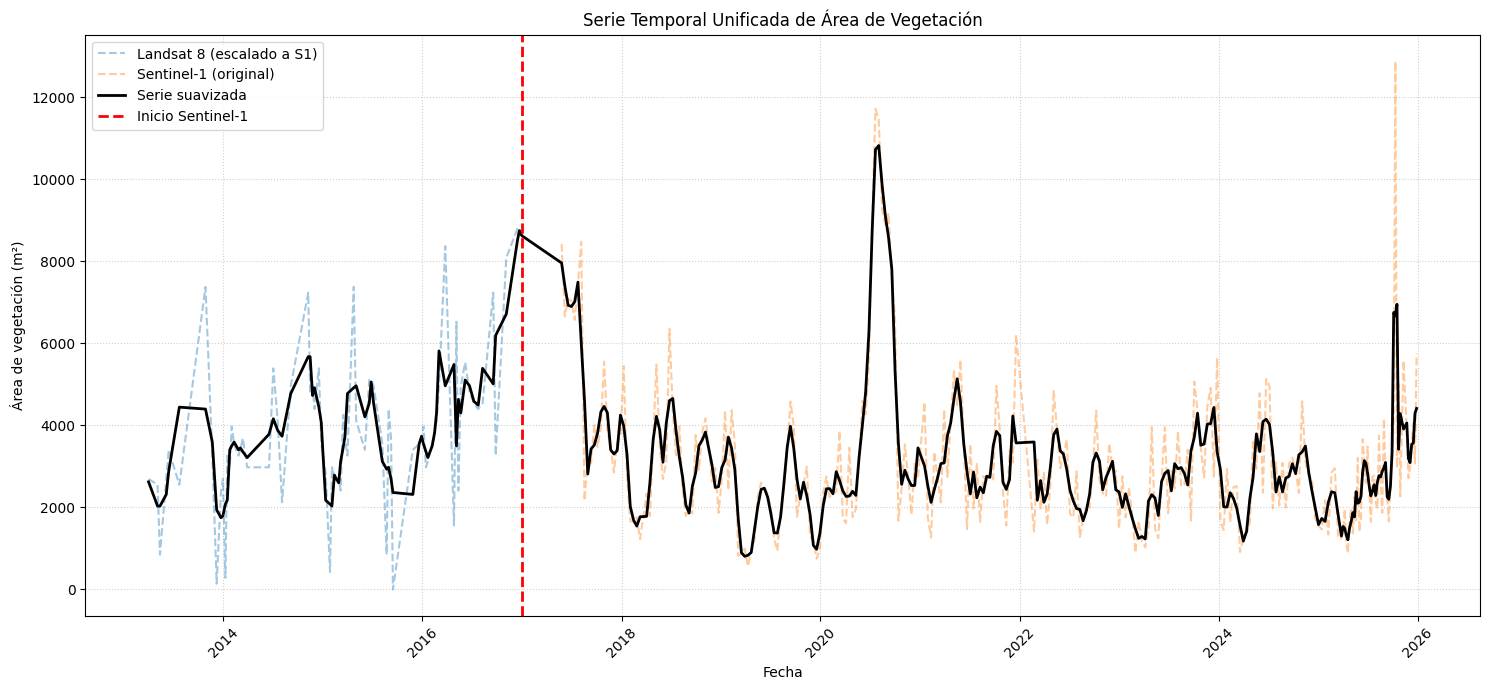

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV
try:
    df_unified_loaded = pd.read_csv('/content/unified_smoothed_series(2).csv')
    print("Archivo cargado exitosamente.")
except FileNotFoundError:
    print("Error: archivo no encontrado.")
    exit()

# Convertir fecha
df_unified_loaded['fecha'] = pd.to_datetime(df_unified_loaded['fecha'])

# Colocar fecha como índice
df_unified_loaded = df_unified_loaded.set_index('fecha')

# Mostrar primeras filas
print("\nPrimeras filas:")
display(df_unified_loaded.head())

# =========================
# VISUALIZACIÓN
# =========================

plt.figure(figsize=(15,7))

# Serie original
sns.lineplot(
    data=df_unified_loaded,
    x=df_unified_loaded.index,
    y='raw_area_m2_vegetacion_unificada',
    hue='fuente',
    linestyle='--',
    alpha=0.4,
    legend=True
)

# Serie suavizada (negra)
plt.plot(
    df_unified_loaded.index,
    df_unified_loaded['smoothed_area'],
    color='black',
    linewidth=2,
    label='Serie suavizada'
)

# Línea vertical inicio Sentinel-1
plt.axvline(
    pd.to_datetime('2017-01-01'),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Sentinel-1'
)

# Diseño
plt.title('Serie Temporal Unificada de Área de Vegetación')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')

plt.grid(True, linestyle=':', alpha=0.6)

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
!pip install -q pycausalimpact
from causalimpact import CausalImpact
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Cargar el CSV
df = pd.read_csv('/content/unified_smoothed_series(2).csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha').sort_index()

# Trabajamos con la serie suavizada como variable principal
# Si tienes NaN en smoothed_area, los interpolamos
df['smoothed_area'] = df['smoothed_area'].interpolate(method='time')

print(df[['smoothed_area']].head())
print(f"\nRango temporal: {df.index.min()} → {df.index.max()}")
print(f"Total observaciones: {len(df)}")

            smoothed_area
fecha                    
2013-04-01    2623.912449
2013-05-04    2032.941008
2013-05-13    2032.940969
2013-06-05    2316.607200
2013-06-14    2883.939775

Rango temporal: 2013-04-01 00:00:00 → 2025-12-28 00:00:00
Total observaciones: 356


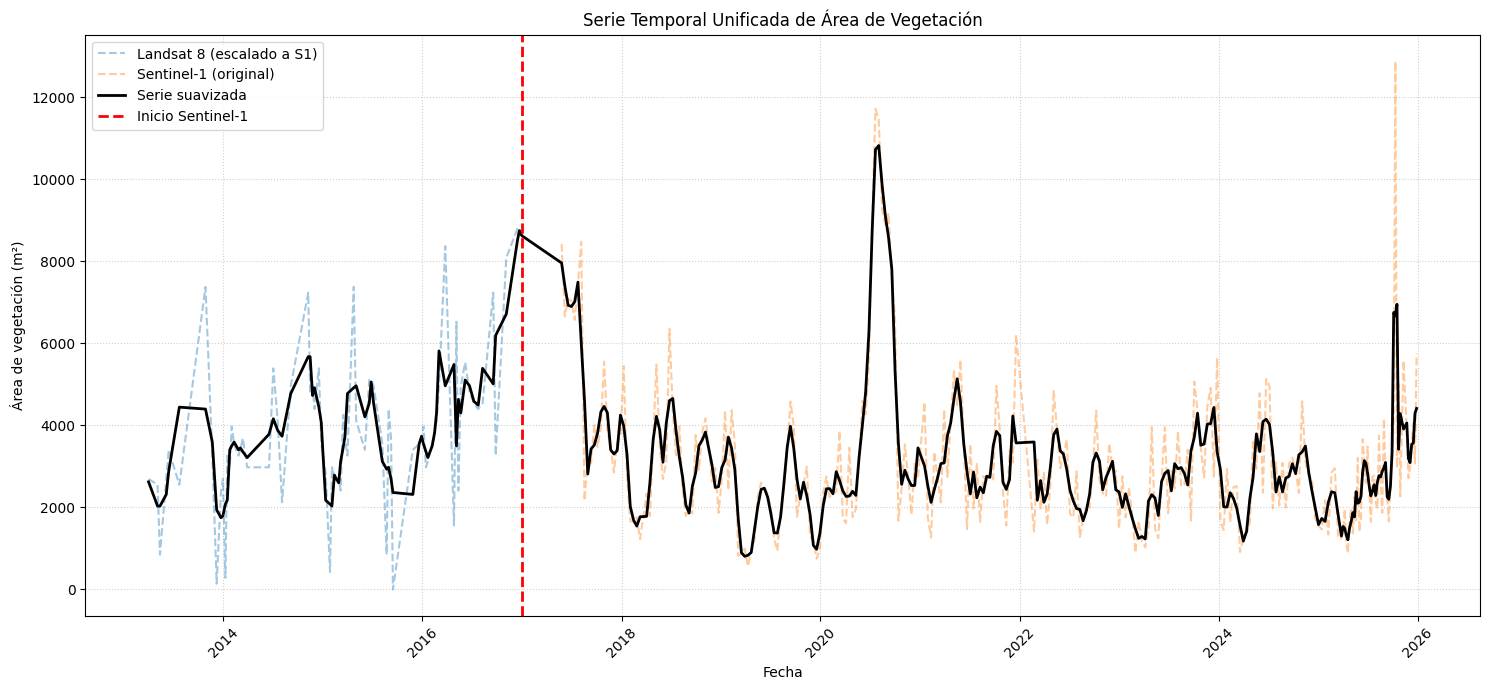

In [21]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=df,
    x=df.index,
    y='raw_area_m2_vegetacion_unificada',
    hue='fuente',
    linestyle='--',
    alpha=0.4,
    legend=True
)

plt.plot(df.index, df['smoothed_area'], color='black', linewidth=2, label='Serie suavizada')

plt.axvline(pd.to_datetime('2017-01-01'), color='red', linestyle='--', linewidth=2, label='Inicio Sentinel-1')

plt.title('Serie Temporal Unificada de Área de Vegetación')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**ITS: Interrupted Time Series**

In [22]:
# Punto de quiebre: inicio de Sentinel-1
BREAKPOINT = '2017-01-01'

# Preparar dataframe para ITS con la serie suavizada
df_its = df[['smoothed_area']].copy()
df_its['y'] = df_its['smoothed_area']

# Variables del modelo ITS
df_its['t']       = range(1, len(df_its) + 1)                        # tendencia global
df_its['evento']  = (df_its.index >= BREAKPOINT).astype(int)         # cambio de nivel (intercepto)
df_its['t_post']  = (df_its.index >= BREAKPOINT).cumsum() * df_its['evento']  # cambio de pendiente
df_its['mes']     = df_its.index.month                                # control estacional

# Modelo OLS con estacionalidad
modelo_its = smf.ols("y ~ t + evento + t_post + C(mes)", data=df_its).fit()
print(modelo_its.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     8.581
Date:                Wed, 13 May 2026   Prob (F-statistic):           6.00e-16
Time:                        04:36:50   Log-Likelihood:                -3074.3
No. Observations:                 356   AIC:                             6179.
Df Residuals:                     341   BIC:                             6237.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1950.9392    389.520      5.009   

| Componente | Qué responde                           |
| ---------- | -------------------------------------- |
| `t`        | tendencia base de la vegetación        |
| `evento`   | salto inmediato en 2017                |
| `t_post`   | cambio de tendencia después del evento |
| `C(mes)`   | estacionalidad                         |


# Conclusión del modelo ITS (Interrupted Time Series)

El modelo de series de tiempo interrumpidas (ITS) aplicado a la serie de vegetación suavizada permite identificar la presencia de un cambio estructural significativo a partir de la fecha de intervención definida (2017-01-01), asociada al inicio de la integración de Sentinel-1 en el sistema de observación.

En términos de ajuste global, el modelo presenta un **R² = 0.261**, lo que indica que aproximadamente el 26.1% de la variabilidad de la serie es explicada por las variables incluidas (tendencia, intervención y estacionalidad). Aunque este valor no es elevado, es consistente con series temporales satelitales, donde es común la presencia de alta variabilidad no explicada debido a factores externos y ruido inherente a la medición.

El modelo en su conjunto es estadísticamente significativo (**F-statistic p-value = 6.00e-16**), lo que indica que las variables incluidas aportan información relevante para explicar el comportamiento de la serie.

---

## Efecto de nivel (intervención)

El coeficiente asociado a la variable **evento** es de **-1842.70 (p < 0.001)**, lo que evidencia un cambio inmediato, abrupto y estadísticamente significativo en el nivel de la serie en el momento de la intervención. Este resultado sugiere una reducción promedio de aproximadamente 1843 unidades en el área de vegetación respecto al nivel esperado bajo la tendencia previa.

Este efecto puede interpretarse como un **cambio estructural fuerte (structural break)** en la serie.

---

## Tendencia antes de la intervención

El coeficiente de la variable de tendencia temporal (**t**) es de **+35.70 (p < 0.001)**, indicando que antes de la intervención la serie presentaba un crecimiento sostenido y estadísticamente significativo, con un incremento promedio de aproximadamente 35 unidades por período.

---

## Cambio en la tendencia posterior

El coeficiente de interacción posterior al evento (**t_post**) es de **-39.64 (p < 0.001)**, lo que indica un cambio significativo en la pendiente de la serie después de la intervención.

Al combinar este efecto con la tendencia previa, se observa que la dinámica pasa de un crecimiento positivo (+35.70) a una tendencia cercana a cero o ligeramente negativa (≈ -4 unidades por período), evidenciando una **inversión en la dinámica de crecimiento de la serie**.

---

##  Efectos estacionales

Los coeficientes asociados a las variables mensuales (**C(mes)**) muestran variaciones significativas en varios meses, lo que confirma la presencia de un patrón estacional en la serie de vegetación. Estos efectos reflejan fluctuaciones periódicas naturales que deben ser controladas para evitar sesgos en la estimación del impacto.

---

## Interpretación

En conjunto, los resultados indican la existencia de:

- Un **cambio inmediato fuerte y estadísticamente significativo en el nivel de la serie**
- Una **alteración estructural en la tendencia de crecimiento**
- Un comportamiento estacional relevante y consistente
- Un modelo globalmente significativo, aunque con capacidad explicativa moderada (R² = 0.261)

---

## Consideración importante

Aunque los resultados sugieren un cambio estructural claro a partir de 2017, este efecto debe interpretarse con cautela, ya que la intervención coincide con un cambio en la fuente de datos (integración de Sentinel-1), lo que podría introducir discontinuidades metodológicas además de posibles cambios reales en la dinámica de la vegetación.

Por lo tanto, el efecto estimado puede reflejar tanto un fenómeno real como un cambio en el sistema de medición.

Visualización del ajuste ITS

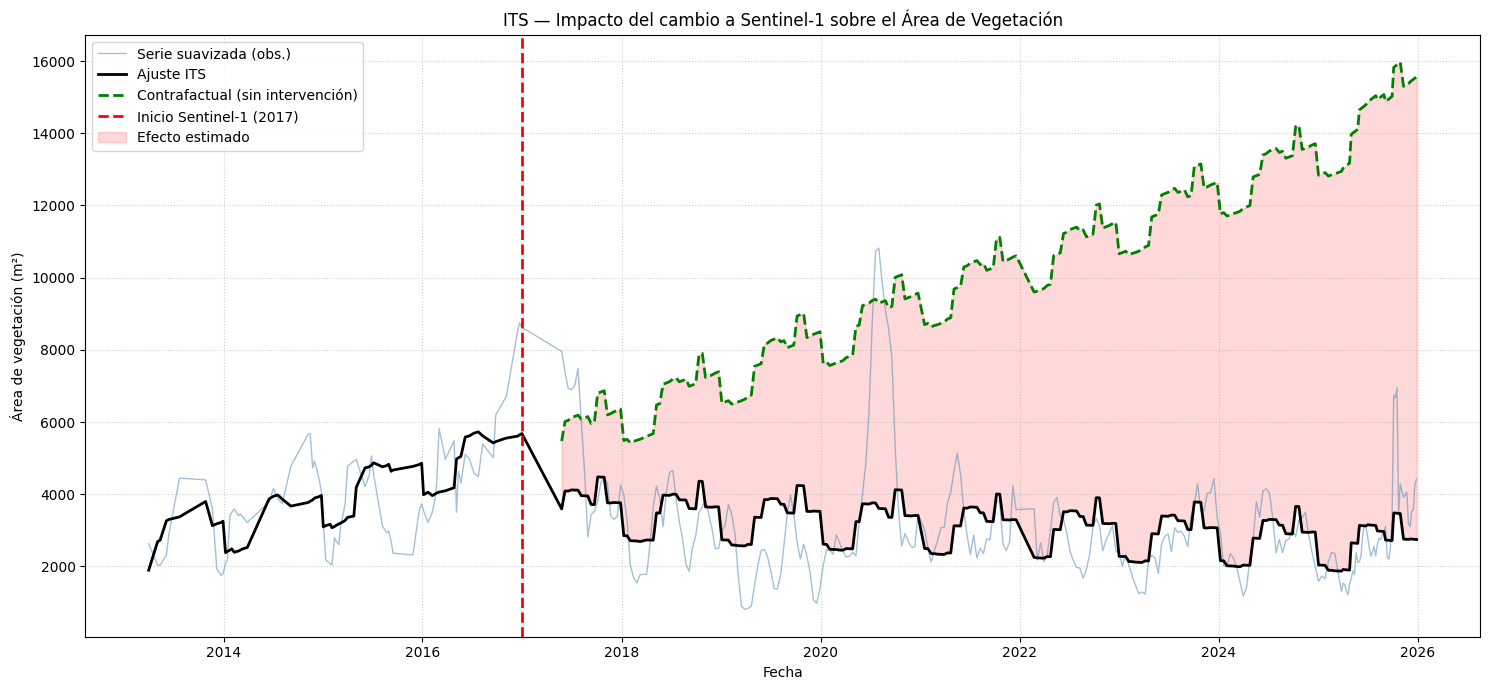

In [23]:
df_its['y_pred'] = modelo_its.fittedvalues

# Contrafactual: predicción post sin el evento
df_its_cf = df_its.copy()
df_its_cf['evento']  = 0
df_its_cf['t_post']  = 0
df_its['y_counterfactual'] = modelo_its.predict(df_its_cf)

plt.figure(figsize=(15, 7))

plt.plot(df_its.index, df_its['y'], color='steelblue', alpha=0.5, linewidth=1, label='Serie suavizada (obs.)')
plt.plot(df_its.index, df_its['y_pred'], color='black', linewidth=2, label='Ajuste ITS')
plt.plot(
    df_its[df_its['evento'] == 1].index,
    df_its[df_its['evento'] == 1]['y_counterfactual'],
    color='green', linewidth=2, linestyle='--', label='Contrafactual (sin intervención)'
)
plt.axvline(pd.to_datetime(BREAKPOINT), color='red', linestyle='--', linewidth=2, label='Inicio Sentinel-1 (2017)')

plt.fill_between(
    df_its[df_its['evento'] == 1].index,
    df_its[df_its['evento'] == 1]['y_counterfactual'],
    df_its[df_its['evento'] == 1]['y_pred'],
    alpha=0.15, color='red', label='Efecto estimado'
)

plt.title('ITS — Impacto del cambio a Sentinel-1 sobre el Área de Vegetación')
plt.xlabel('Fecha')
plt.ylabel('Área de vegetación (m²)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

La gráfica se interpreta comparando tres elementos: la serie observada (línea azul), el ajuste del modelo ITS (línea negra) y el contrafactual sin intervención (línea verde punteada). Antes de 2017, el modelo reproduce bien el comportamiento de la serie, lo que indica una buena calibración en el periodo pre-intervención. A partir del punto de corte (línea roja), la serie observada se desvía del contrafactual, mostrando un nivel menor al esperado. Esta diferencia se interpreta como el efecto estimado del evento, evidenciado por el área sombreada en rojo, y sugiere un impacto negativo estructural en el área de vegetación tras la incorporación de Sentinel-1, en comparación con el escenario hipotético sin intervención.

#**CausalImpact (Espacio de Estados Bayesiano)**

Pre-period actual: [Timestamp('2013-04-01 00:00:00'), Timestamp('2016-12-31 00:00:00')]
Post-period actual: [Timestamp('2017-05-26 00:00:00'), Timestamp('2025-12-28 00:00:00')]
Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    3106.1             860389.12
Prediction (s.d.)         5370.59 (926.19)   1487653.09 (256555.42)
95% CI                    [3553.19, 7183.8]  [984233.82, 1989912.58]

Absolute effect (s.d.)    -2264.49 (926.19)  -627263.97 (256555.42)
95% CI                    [-4077.7, -447.09] [-1129523.45, -123844.69]

Relative effect (s.d.)    -42.16% (17.25%)   -42.16% (17.25%)
95% CI                    [-75.93%, -8.32%]  [-75.93%, -8.32%]

Posterior tail-area probability p: 0.01
Posterior prob. of a causal effect: 99.4%

For more details run the command: print(impact.summary('report'))


Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of appro

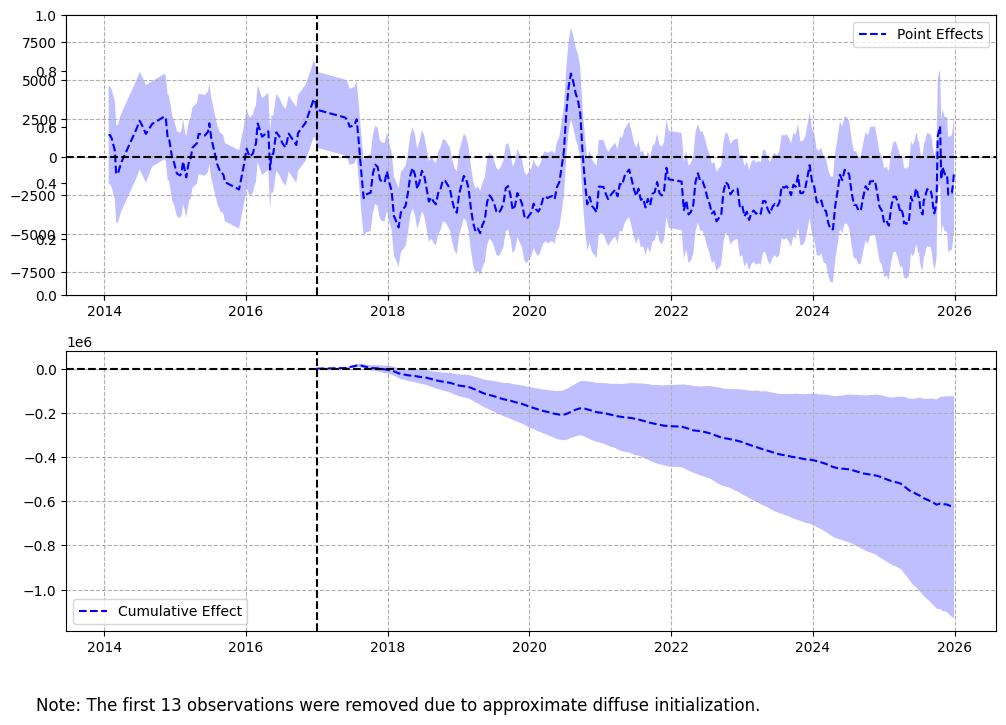

In [26]:
# Definir periodos pre y post intervención
# Usa fechas que existan en tu índice; ajusta si tu frecuencia no es mensual exacto

# Serie para CausalImpact (debe ser un pd.Series con índice DatetimeIndex)
serie_ci = df['smoothed_area'].dropna()

# Define the nominal intervention date
nominal_intervention_date = pd.to_datetime('2017-01-01')

# Find the last date in the series before the nominal intervention date
pre_period_end_actual = serie_ci.index[serie_ci.index < nominal_intervention_date].max()

# Find the first date in the series on or after the nominal intervention date
post_period_start_actual = serie_ci.index[serie_ci.index >= nominal_intervention_date].min()

# Define pre_period and post_period using actual dates from the index
pre_period  = [serie_ci.index.min(), pre_period_end_actual]
post_period = [post_period_start_actual, serie_ci.index.max()]

print(f"Pre-period actual: {pre_period}")
print(f"Post-period actual: {post_period}")

# Ajustar modelo
ci = CausalImpact(
    serie_ci,
    pre_period,
    post_period,
    nseasons=[{'period': 12}],   # captura estacionalidad anual
    prior_level_sd=0.05          # prior conservador (igual que en tu taller)
)

# 5. Resultados
print(ci.summary())
print("\n")
print(ci.summary('report'))

# 6. Gráfica
ci.plot(panels=['pointwise', 'cumulative'], figsize=(12, 8))

#**Interpretación de los Resultados y Gráfica de Causal Impact**

El análisis de Causal Impact confirmó que la intervención (el cambio en la fuente de datos a Sentinel-1) tuvo un efecto causal negativo y estadísticamente muy significativo en el área de vegetación. Aquí los puntos clave:

* Efecto Absoluto: Durante el período posterior a la intervención, el área de vegetación promedio observada fue de 3106.1 m². Sin la intervención, se habría esperado un promedio de 5370.59 m². Esto implica una disminución estimada de -2264.49 m².
* Efecto Relativo: Esto representa una disminución relativa del -42.16% del área de vegetación promedio en el período post-intervención, en comparación con el escenario contrafactual (lo que habría ocurrido sin la intervención).
* Significancia Estadística: La probabilidad de observar este efecto por casualidad es muy baja (p = 0.01), con una probabilidad del 99.4% de que exista un efecto causal real.

La gráfica de Causal Impact visualiza esto mostrando:

* Panel Superior (Pointwise): La serie observada (línea azul) comparada con la predicción contrafactual (línea discontinua verde) para el período post-intervención. La diferencia entre ambas representa el efecto punto a punto. Verás cómo la línea azul cae significativamente por debajo de la verde, lo que indica el impacto negativo.
* Panel Inferior (Cumulative): Muestra el efecto acumulado a lo largo del tiempo. Aquí también se observa una desviación negativa creciente de la serie observada respecto al contrafactual, consolidando la idea de un impacto sostenido.


# **Conclusión Final**

Ambas metodologías (ITS y Causal Impact) convergen en una conclusión clara: la introducción de Sentinel-1 como fuente de datos para el monitoreo del área de vegetación a partir de 2017 se asocia con una disminución robusta y estadísticamente significativa en el área de vegetación. Esta disminución se manifiesta tanto en un cambio de nivel inmediato como en una alteración de la tendencia, resultando en un área de vegetación que es sustancialmente menor de lo que se habría esperado si el cambio de fuente de datos no hubiera ocurrido.



**Resumen del Notebook**

Este notebook analizó una serie temporal de área de vegetación para detectar el impacto del cambio de Landsat 8 a Sentinel-1 alrededor de 2017. Utilizando Análisis de Series Temporales Interrumpidas (ITS) y Causal Impact, se encontró una reducción significativa y estadísticamente robusta en el área de vegetación post-intervención, con una disminución de aproximadamente el 42% respecto a lo esperado.